In [1]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import os

C:\Users\kursa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from kagglehub import KaggleDatasetAdapter

In [4]:
df = pd.read_csv("Dataset/toyota.csv")

In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [6]:
df.describe() #verileri analiz ediyoruz

,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.697240,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.880776,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


In [7]:
df.isnull().sum()  # boş verimiz yokmuş

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Figure size 700x500 with 0 Axes>

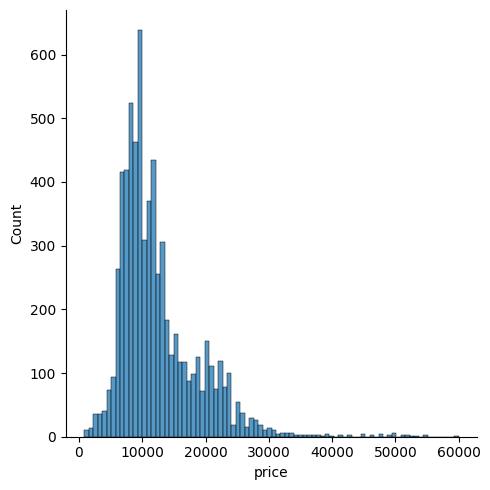

In [8]:
plt.figure(figsize=(7,5))
sbn.displot(df["price"])   # grafikte aşırı pahalı araçlardan dolayı bizi yanıltabiliriz bu grafikten yüksek fiyatlı araçları çıkartmak

<Axes: ylabel='count'>

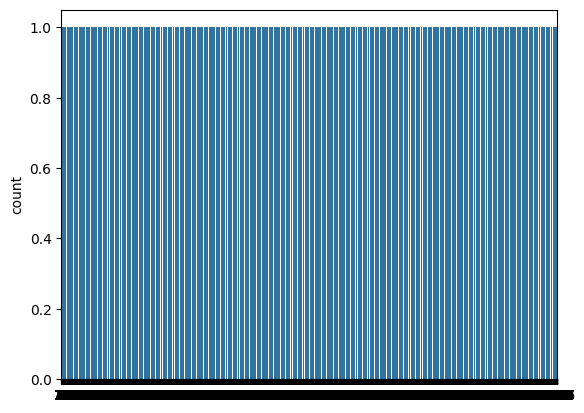

In [9]:
sbn.countplot(df["year"])

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"]) #sadece sayısal sütunları seçtik
numeric_df.corr()

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.420959,-0.727749,0.283455,-0.020607,-0.045567
price,0.420959,1.000000,-0.297936,0.214498,-0.039910,0.727592
mileage,-0.727749,-0.297936,1.000000,-0.205285,0.044889,0.182615
tax,0.283455,0.214498,-0.205285,1.000000,-0.430292,0.155727
mpg,-0.020607,-0.039910,0.044889,-0.430292,1.000000,-0.106868
engineSize,-0.045567,0.727592,0.182615,0.155727,-0.106868,1.000000


In [11]:
numeric_df.corr()["price"].sort_values()  #fiyatın diger degişkenlenler  ile korelasyonuna bakıyoruz aralarındaki ilişkileri

mileage      -0.297936
mpg          -0.039910
tax           0.214498
year          0.420959
engineSize    0.727592
price         1.000000
Name: price, dtype: float64

<Axes: xlabel='mileage', ylabel='price'>

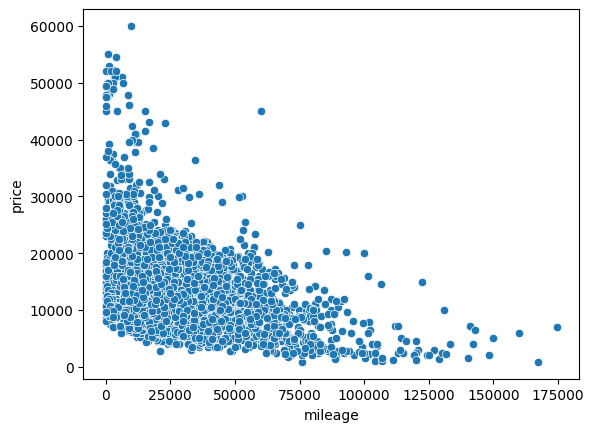

In [12]:
sbn.scatterplot(x="mileage",y="price",data=df)

In [13]:
df.sort_values("price",ascending=False).head(20)   #pahalıları üstten asagı sonuçlandırıyoruz ,ascending yükselen demek

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
6711,Supra,2019,59995,Automatic,9909,Other,150,34.5,3.0
6670,Land Cruiser,2019,54991,Semi-Auto,1000,Diesel,145,30.1,2.8
6695,Land Cruiser,2020,54550,Automatic,4000,Diesel,150,30.1,2.8
6688,Land Cruiser,2020,52990,Automatic,1244,Diesel,145,30.1,2.8
6672,Land Cruiser,2020,52291,Semi-Auto,3104,Diesel,145,30.1,2.8
6707,Supra,2019,51995,Semi-Auto,4153,Petrol,145,34.5,3.0
6704,Supra,2019,51995,Semi-Auto,1902,Petrol,145,34.5,3.0
6703,Supra,2019,51995,Semi-Auto,250,Petrol,145,34.5,3.0
6667,Land Cruiser,2019,50995,Semi-Auto,6254,Diesel,145,30.1,2.8
6661,Land Cruiser,2020,50995,Semi-Auto,3390,Diesel,145,30.1,2.8


In [14]:
len(df)

6738

In [15]:
len(df) * 0.01   # yüzde 1i  en yüksek 67 arabayı atıcaz 

67.38

In [22]:
yuzdeDoksanDokuzVeri = df.sort_values("price",ascending= False).iloc[67:]

In [25]:
yuzdeDoksanDokuzVeri.describe()  #veriler fazla bozulmadan düzenledik fiyatlarının pahalı olanlardan asagı dogru 67 tanesini attık

,year,price,mileage,tax,mpg,engineSize
count,6671.000000,6671.000000,6671.000000,6671.000000,6671.000000,6671.000000
mean,2016.727027,12220.171039,23011.699895,94.003148,63.308844,1.458522
std,2.201945,5564.558938,19136.412768,73.647191,15.659486,0.418047
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8250.000000,9600.500000,0.000000,55.400000,1.000000
50%,2017.000000,10730.000000,18686.000000,135.000000,62.800000,1.500000
75%,2018.000000,14855.000000,31183.000000,145.000000,70.600000,1.800000
max,2020.000000,32990.000000,174419.000000,565.000000,235.000000,4.200000


C:\Users\kursa\AppData\Local\Temp\ipykernel_7400\3206817674.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(yuzdeDoksanDokuzVeri["price"])


<Axes: xlabel='price', ylabel='Density'>

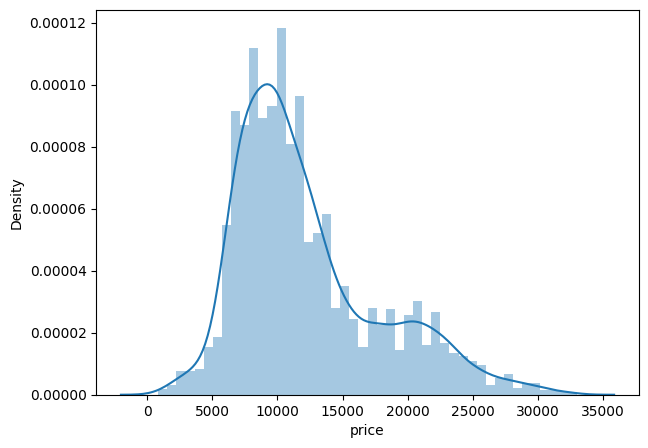

In [29]:
plt.figure(figsize=(7,5))
sbn.distplot(yuzdeDoksanDokuzVeri["price"])

In [35]:
yearGroup = df.groupby("year")

In [37]:
yearGroup["price"].mean()

year
1998    19990.000000
1999     1995.000000
2000     2695.000000
2001      899.000000
2002     1811.000000
2003     1984.166667
2004     3893.571429
2005     3054.416667
2006     3109.454545
2007     2797.500000
2008     3926.210526
2009     4160.413793
2010     5397.500000
2011     5341.425000
2012     6634.595238
2013     8404.656863
2014     9065.571023
2015     9909.577143
2016    11704.079238
2017    12187.601288
2018    12382.222660
2019    16718.916796
2020    22968.671875
Name: price, dtype: float64

In [42]:
pd.DataFrame(yearGroup)

,0,1
0,1998,model year price transmission ...
1,1999,model year price transmission mileag...
2,2000,model year price transmission mileag...
3,2001,model year price transmission milea...
4,2002,model year price transmission mileag...
5,2003,model year price transmission mile...
6,2004,model year price transmission ...
7,2005,model year price transmission ...
8,2006,model year price transmission ...
9,2007,model year price transmission mile...


In [54]:
df[df.year != 1970].groupby("year").mean(numeric_only=True)["price"]   # sadece sayısal kolonları al numeric only True yoksa hata verir

year
1998    19990.000000
1999     1995.000000
2000     2695.000000
2001      899.000000
2002     1811.000000
2003     1984.166667
2004     3893.571429
2005     3054.416667
2006     3109.454545
2007     2797.500000
2008     3926.210526
2009     4160.413793
2010     5397.500000
2011     5341.425000
2012     6634.595238
2013     8404.656863
2014     9065.571023
2015     9909.577143
2016    11704.079238
2017    12187.601288
2018    12382.222660
2019    16718.916796
2020    22968.671875
Name: price, dtype: float64

In [55]:
df = yuzdeDoksanDokuzVeri

In [56]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6671.000000,6671.000000,6671.000000,6671.000000,6671.000000,6671.000000
mean,2016.727027,12220.171039,23011.699895,94.003148,63.308844,1.458522
std,2.201945,5564.558938,19136.412768,73.647191,15.659486,0.418047
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8250.000000,9600.500000,0.000000,55.400000,1.000000
50%,2017.000000,10730.000000,18686.000000,135.000000,62.800000,1.500000
75%,2018.000000,14855.000000,31183.000000,145.000000,70.600000,1.800000
max,2020.000000,32990.000000,174419.000000,565.000000,235.000000,4.200000


In [57]:
df = df[df.year != 1970]

In [59]:
df.groupby("year").mean(numeric_only=True)["price"]

year
1998    19990.000000
1999     1995.000000
2000     2695.000000
2001      899.000000
2002     1811.000000
2003     1984.166667
2004     3893.571429
2005     3054.416667
2006     3109.454545
2007     2797.500000
2008     3926.210526
2009     4160.413793
2010     5397.500000
2011     5341.425000
2012     6634.595238
2013     8404.656863
2014     8963.222222
2015     9860.368321
2016    11682.697791
2017    12111.610532
2018    12353.507890
2019    15832.016881
2020    20103.159292
Name: price, dtype: float64

In [62]:
df[df.year != 1998].groupby("year").mean(numeric_only=True)["price"]

year
1999     1995.000000
2000     2695.000000
2001      899.000000
2002     1811.000000
2003     1984.166667
2004     3893.571429
2005     3054.416667
2006     3109.454545
2007     2797.500000
2008     3926.210526
2009     4160.413793
2010     5397.500000
2011     5341.425000
2012     6634.595238
2013     8404.656863
2014     8963.222222
2015     9860.368321
2016    11682.697791
2017    12111.610532
2018    12353.507890
2019    15832.016881
2020    20103.159292
Name: price, dtype: float64

In [63]:
df = df[df.year != 1998]

In [64]:
df.groupby("year").mean(numeric_only=True)["price"]

year
1999     1995.000000
2000     2695.000000
2001      899.000000
2002     1811.000000
2003     1984.166667
2004     3893.571429
2005     3054.416667
2006     3109.454545
2007     2797.500000
2008     3926.210526
2009     4160.413793
2010     5397.500000
2011     5341.425000
2012     6634.595238
2013     8404.656863
2014     8963.222222
2015     9860.368321
2016    11682.697791
2017    12111.610532
2018    12353.507890
2019    15832.016881
2020    20103.159292
Name: price, dtype: float64

In [66]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
782,RAV4,2019,32990,Automatic,5944,Hybrid,135,49.6,2.5
556,RAV4,2019,32860,Automatic,4271,Hybrid,135,49.6,2.5
6652,Land Cruiser,2015,32498,Automatic,16871,Diesel,325,34.9,3.0
626,RAV4,2019,32495,Automatic,12740,Hybrid,135,49.6,2.5
426,RAV4,2019,31995,Automatic,11970,Hybrid,140,49.6,2.5
427,RAV4,2019,31995,Automatic,11728,Hybrid,140,49.6,2.5
6244,Prius,2020,31995,Automatic,100,Hybrid,135,217.3,1.8
6668,Land Cruiser,2016,31990,Semi-Auto,43996,Diesel,305,38.2,2.8
496,RAV4,2020,31790,Automatic,1652,Hybrid,135,49.6,2.5
369,RAV4,2019,31498,Automatic,9258,Hybrid,135,49.6,2.5


In [67]:
df = df.drop("transmission",axis=1)  #axis =1 üstten aşagı demek vitese ihtiyacımız yok

In [75]:
df = df.drop("model",axis=1)

KeyError: "['model'] not found in axis"

In [76]:
df.head()

,year,price,mileage,fuelType,tax,mpg,engineSize
782,2019,32990,5944,Hybrid,135,49.6,2.5
556,2019,32860,4271,Hybrid,135,49.6,2.5
6652,2015,32498,16871,Diesel,325,34.9,3.0
626,2019,32495,12740,Hybrid,135,49.6,2.5
426,2019,31995,11970,Hybrid,140,49.6,2.5


In [79]:
y = df["price"].values
x = df.drop("price",axis=1).values

In [80]:
y

array([32990, 32860, 32498, ...,   950,   899,   850])

In [81]:
x

array([[2.01900e+03, 5.94400e+03, 1.35000e+02, 4.96000e+01, 2.50000e+00],
       [2.01900e+03, 4.27100e+03, 1.35000e+02, 4.96000e+01, 2.50000e+00],
       [2.01500e+03, 1.68710e+04, 3.25000e+02, 3.49000e+01, 3.00000e+00],
       ...,
       [2.00200e+03, 1.04000e+05, 2.00000e+02, 4.04000e+01, 1.50000e+00],
       [2.00100e+03, 7.60000e+04, 3.00000e+02, 3.53000e+01, 1.60000e+00],
       [2.00300e+03, 1.67054e+05, 2.05000e+02, 4.87000e+01, 2.00000e+00]])

In [77]:
df = df.drop("fuelType",axis=1)

In [78]:
df.head()

,year,price,mileage,tax,mpg,engineSize
782,2019,32990,5944,135,49.6,2.5
556,2019,32860,4271,135,49.6,2.5
6652,2015,32498,16871,325,34.9,3.0
626,2019,32495,12740,135,49.6,2.5
426,2019,31995,11970,140,49.6,2.5


In [82]:
from sklearn.model_selection import train_test_split

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=10)

In [84]:
len(x_train)

4468

In [85]:
len(x_test)

2202

In [86]:
from sklearn.preprocessing import MinMaxScaler

In [89]:
scaler = MinMaxScaler()

In [90]:
x_train = scaler.fit_transform(x_train)

In [91]:
x_text = scaler.fit_transform(x_test)

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [93]:
x_train.shape

(4468, 5)

In [128]:
model = Sequential()

model.add(Dense(6,activation="relu"))  #12 nöron koyduk
model.add(Dense(6,activation="relu"))
model.add(Dense(6,activation="relu"))
model.add(Dense(6,activation="relu"))

model.add(Dense(1)) #çıkış katmanı


model.compile(optimizer="adam",loss="mse")


In [129]:
model.fit(x=x_train, y= y_train,validation_data = (x_test,y_test),batch_size=250, epochs=200)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 178962448.0000 - val_loss: 168704928.0000
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178959504.0000 - val_loss: 147606160.0000
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178955408.0000 - val_loss: 125459400.0000
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178949664.0000 - val_loss: 110638024.0000
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178940816.0000 - val_loss: 132076976.0000
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178927664.0000 - val_loss: 248071840.0000
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178908352.0000 - val_loss: 573995328.0000
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178881008.0000 - val_loss: 1322050816.0000
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178842960.0000 - val_loss: 2805231872.0000
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178791280.0000 - val_loss: 56

In [130]:
kayipVerisi = pd.DataFrame(model.history.history)

In [131]:
kayipVerisi.head()

,loss,val_loss
0,178962448.0,168704928.0
1,178959504.0,147606160.0
2,178955408.0,125459400.0
3,178949664.0,110638024.0
4,178940816.0,132076976.0


<Axes: >

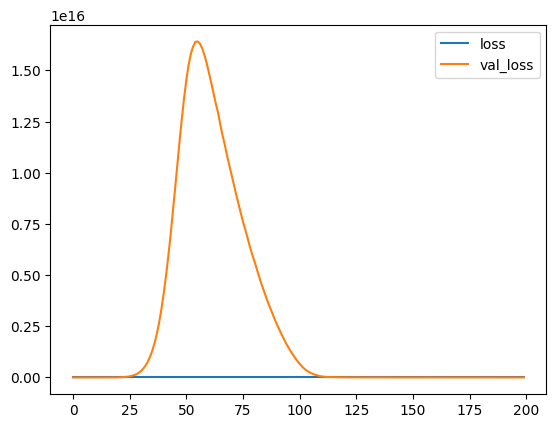

In [132]:
kayipVerisi.plot()

In [134]:
tahminDizisi = model.predict(x_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [135]:
tahminDizisi

array([[68.879425],
       [68.879425],
       [68.879425],
       ...,
       [68.879425],
       [68.879425],
       [68.879425]], dtype=float32)

In [138]:
mean_absolute_error(y_test,tahminDizisi)

219612.265625

In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [139]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000
mean,2016.729835,12219.006147,23000.157421,93.977511,63.314753,1.458111
std,2.190136,5564.162602,19114.609670,73.622937,15.653222,0.416729
min,1999.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8250.000000,9600.250000,0.000000,55.400000,1.000000
50%,2017.000000,10727.500000,18684.500000,135.000000,62.800000,1.500000
75%,2018.000000,14849.750000,31182.750000,145.000000,70.600000,1.800000
max,2020.000000,32990.000000,174419.000000,565.000000,235.000000,3.000000


In [143]:
mean_absolute_error(y_test,tahminDizisi) / df["price"].mean()   # %17lik bir fark var

np.float64(17.973005577073007)

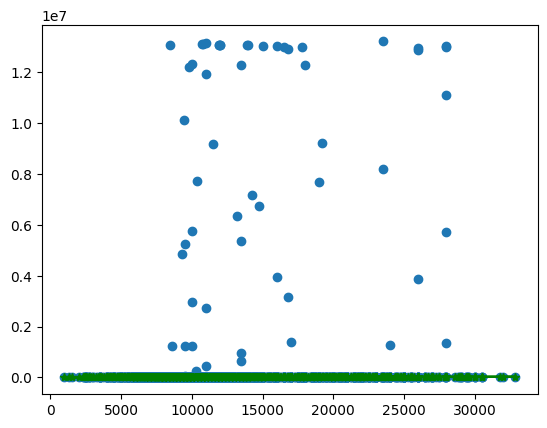

In [145]:
plt.scatter(y_test,tahminDizisi)
plt.plot(y_test,y_test,"g-*")  #bozuk çıktı dogrusallık yok bende